## 07. Temporal Model Validation Using Historical Training Data

### Research Question 3 (Part b)

**To what extent can a model trained using historical the 2011 Toronto Neighbourhood Profiles dataset accurately predict neighbourhood-level low-income prevalence in the independent 2016 dataset?**

### Section-1 Objective

Develop and evaluate machine learning models using the 2011 Toronto Neighbourhood Profiles as the training dataset and the 2016 Toronto Neighbourhood Profiles as the testing dataset. This notebook evaluates the temporal generalizability of neighbourhood-level predictive models by assessing how well historical socioeconomic relationships predict future low-income prevalence.

Unlike Notebook 4, which used a random train-test split within the 2016 dataset, this notebook performs **temporal validation**, where models are trained using historical observations and evaluated on future data. This approach provides a more realistic assessment of model performance over time.

### Input

| File | Description |
|------|-------------|
| `data/processed/neighbourhood_profiles_2011_ml_ready.csv` | Training dataset (2011) |
| `data/processed/neighbourhood_profiles_2016_ml_ready.csv` | Testing dataset (2016) |

### Output

- Temporal training dataset
- Temporal testing dataset
- Linear Regression temporal validation
- Random Forest temporal validation
- Model evaluation metrics
- Residual analysis
- Feature importance
- Temporal model performance comparison

In [38]:
# Import libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error)

# Statistical Analysis
import scipy.stats as stats

# Display options
pd.set_option("display.max_columns", None)

In [39]:
from pathlib import Path

# Project directory
project_dir = Path.cwd().parent.parent

# Data directory
data_dir = project_dir / "data" / "processed"

print("=" * 60)
print("Project Directory")
print("=" * 60)

print(project_dir)

print("\nProcessed Data Directory")
print(data_dir)

Project Directory
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project

Processed Data Directory
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\data\processed


### Section-2 Load Training Dataset (2011)

Load the 2011 machine learning-ready dataset that will be used as the training dataset for model development. This historical dataset provides the socioeconomic indicators and corresponding neighbourhood low-income prevalence used to train the predictive models.

In [40]:
# Load the 2011 training dataset

train_df = pd.read_csv(
    data_dir / "neighbourhood_profiles_2011_ml_ready.csv")

print("=" * 60)
print("Training Dataset Summary (2011)")
print("=" * 60)

print(f"Rows: {train_df.shape[0]}")
print(f"Columns: {train_df.shape[1]}")

display(train_df.head())

Training Dataset Summary (2011)
Rows: 140
Columns: 12


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Visible_Minority,Renters,Immigrant_Population,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,Agincourt North,30279.0,57.9,51.3,11.3,3530.0,5965.0,27025.0,1805.0,21490.0,1595.0,18.8
1,Agincourt South-Malvern West,21988.0,59.3,53.0,10.7,2520.0,4070.0,17780.0,1640.0,14225.0,1245.0,17.9
2,Alderwood,11904.0,66.0,61.1,7.4,1170.0,2290.0,1955.0,1025.0,4165.0,710.0,9.4
3,Annex,29177.0,71.8,66.6,7.3,6040.0,1690.0,6010.0,9780.0,8560.0,870.0,20.3
4,Banbury-Don Mills,26918.0,61.3,57.0,7.1,4370.0,2300.0,11930.0,4730.0,12765.0,1165.0,12.8


### Section-3 Load Testing Dataset (2016)

Load the 2016 machine learning-ready dataset that will be used as the testing dataset for temporal validation. This dataset represents future observations and will be used to evaluate how well models trained on the 2011 data generalize to neighbourhood socioeconomic conditions in 2016.

In [41]:
# Load the 2016 testing dataset

test_df = pd.read_csv(
    data_dir / "neighbourhood_profiles_2016_ml_ready.csv")

print("=" * 60)
print("Testing Dataset Summary (2016)")
print("=" * 60)

print(f"Rows: {test_df.shape[0]}")
print(f"Columns: {test_df.shape[1]}")

display(test_df.head())

Testing Dataset Summary (2016)
Rows: 141
Columns: 14


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree,No_Diploma,Immigrant_Population,Visible_Minority,Renters,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families,Low_Income_AfterTax_Pct
0,City of Toronto,2731571,64.7,59.3,8.2,534610,561090,1266005,1385855,525835,240780,36.6,152595,20.2
1,Agincourt North,29113,55.4,50.0,9.8,4380,7460,19995,26365,1720,2220,34.7,1650,21.3
2,Agincourt South-Malvern West,23757,59.0,53.2,9.8,4210,6090,15095,20155,2250,1795,38.2,1360,22.6
3,Alderwood,12054,66.5,62.4,6.1,1660,2960,3970,2490,950,540,21.7,670,8.2
4,Annex,30526,70.6,65.8,6.7,9135,4270,8270,7270,9870,2420,40.4,895,18.3


### Section-4. Define Training Features and Target Variable

Define the common independent variables and the dependent variable used for temporal model validation. Using an identical feature set for both the 2011 training dataset and the 2016 testing dataset ensures a fair and consistent evaluation of model performance over time.

In [42]:
# Define independent variables (common to both datasets)

features = [

    "Population",
    "Participation_Rate",
    "Employment_Rate",
    "Unemployment_Rate",
    "Bachelors_Degree",
    "No_Diploma",
    "Visible_Minority",
    "Renters",
    "Immigrant_Population",
    "Lone_Parent_Families"]

# Define dependent variable

target = "Low_Income_AfterTax_Pct"

print("=" * 60)
print("Feature Selection Summary")
print("=" * 60)

print(f"Independent Variables ({len(features)}):")

for feature in features:
    print(f"- {feature}")

print("\nDependent Variable:")
print(f"- {target}")

Feature Selection Summary
Independent Variables (10):
- Population
- Participation_Rate
- Employment_Rate
- Unemployment_Rate
- Bachelors_Degree
- No_Diploma
- Visible_Minority
- Renters
- Immigrant_Population
- Lone_Parent_Families

Dependent Variable:
- Low_Income_AfterTax_Pct


### Interpretation

Ten common socioeconomic indicators were selected as the independent variables for temporal model validation, while **Low_Income_AfterTax_Pct** was defined as the dependent variable. These variables are available in both the 2011 and 2016 machine learning-ready datasets, ensuring that the predictive models are trained and evaluated using a consistent feature set.

The exclusion of **Core_Housing_Need** and **Unaffordable_Housing** is intentional because these variables are only available in the 2016 dataset. Restricting the analysis to the common variables preserves the validity of the temporal comparison and ensures that differences in model performance reflect temporal generalization rather than differences in available predictors.

### Section-7 Prepare Training and Testing Matrices

Construct the feature matrices and target vectors for temporal model validation. The 2011 dataset is used exclusively for model training, while the 2016 dataset is reserved for model testing, ensuring that predictive performance is evaluated on future observations.

In [43]:
# Remove the City of Toronto aggregate row

test_df = (    test_df[
        test_df["Neighbourhood"] != "City of Toronto"
    ]    .reset_index(drop=True))
print(f"Rows: {test_df.shape[0]}")

Rows: 140


In [44]:
# Create training and testing matrices

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("=" * 60)
print("Training and Testing Dataset Summary")
print("=" * 60)

print(f"X_train Shape: {X_train.shape}")
print(f"y_train Shape: {y_train.shape}")

print()

print(f"X_test Shape: {X_test.shape}")
print(f"y_test Shape: {y_test.shape}")

Training and Testing Dataset Summary
X_train Shape: (140, 10)
y_train Shape: (140,)

X_test Shape: (140, 10)
y_test Shape: (140,)


### Section-8 Train the Linear Regression Model

Train a Linear Regression model using the 2011 neighbourhood socioeconomic indicators and the corresponding neighbourhood low-income prevalence values. The trained model will learn the relationships between the selected socioeconomic indicators and the target variable before being applied to the 2016 dataset for temporal validation.

In [45]:
# Initialize the Linear Regression model

lr_model = LinearRegression()

# Train the model using the 2011 dataset

lr_model.fit(X_train, y_train)

print("=" * 60)
print("Linear Regression Model Training")
print("=" * 60)

print("Model trained successfully.")

print(f"Training Samples: {X_train.shape[0]}")
print(f"Training Features: {X_train.shape[1]}")

Linear Regression Model Training
Model trained successfully.
Training Samples: 140
Training Features: 10


### Interpretation

The Linear Regression model was successfully trained using the 2011 neighbourhood dataset. During training, the model learned the relationships between the ten selected socioeconomic indicators (independent variables) and neighbourhood low-income prevalence (dependent variable).

Unlike the predictive model developed in Notebook 4, this model has not been exposed to any observations from the 2016 dataset. Consequently, its performance on the 2016 data will provide an objective assessment of how well socioeconomic relationships learned from historical data generalize to future neighbourhood conditions.

### Section-9. Examine Linear Regression Coefficients

Extract and examine the Linear Regression coefficients learned from the 2011 training dataset. The regression coefficients quantify the direction and magnitude of the relationship between each socioeconomic indicator and neighbourhood-level low-income prevalence, providing insight into the variables that influence model predictions.

In [46]:
# Extract Linear Regression coefficients

coef_df = pd.DataFrame({

    "Variable": features,
    "Coefficient": lr_model.coef_})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("Linear Regression Coefficients")
print("=" * 60)

display(coef_df)

Linear Regression Coefficients


,Variable,Coefficient
0,Unemployment_Rate,2.677028
1,Employment_Rate,2.017331
2,Renters,0.002095
3,Lone_Parent_Families,0.001238
4,Bachelors_Degree,0.000428
5,Immigrant_Population,0.000348
6,Visible_Minority,0.000292
7,No_Diploma,-0.000218
8,Population,-0.000811
9,Participation_Rate,-2.062089


### Interpretation

The Linear Regression coefficients quantify the relationships learned from the 2011 training dataset between the selected socioeconomic indicators and neighbourhood-level low-income prevalence.

Among the ten independent variables, **Unemployment_Rate** (2.677) exhibited the strongest positive association with low-income prevalence, indicating that neighbourhoods with higher unemployment rates were predicted to have higher levels of low-income prevalence. **Employment_Rate** (2.017) also showed a positive relationship, suggesting that its effect should be interpreted alongside the other socioeconomic variables in the multivariate model rather than in isolation.

Conversely, **Participation_Rate** (-2.062) demonstrated the strongest negative association with low-income prevalence, indicating that neighbourhoods with higher labour force participation tended to have lower predicted low-income prevalence after accounting for the other predictors. The remaining variables exhibited comparatively smaller coefficients, suggesting more modest contributions to the model's predictions.

These coefficients represent the socioeconomic relationships learned from the 2011 data and provide the foundation for predicting neighbourhood-level low-income prevalence in the 2016 testing dataset. The next stage of the analysis evaluates whether these historical relationships remain predictive when applied to future neighbourhood observations.

### Section-10 Generate Predictions for the 2016 Testing Dataset

Apply the Linear Regression model trained on the 2011 dataset to the 2016 testing dataset and generate predicted neighbourhood-level low-income prevalence values. These predictions will be compared with the observed 2016 values to evaluate the model's temporal predictive performance.

In [47]:
# Generate predictions for the 2016 testing dataset

y_pred_lr = lr_model.predict(X_test)

# Create prediction results

prediction_df = pd.DataFrame({

    "Neighbourhood": test_df["Neighbourhood"],
    "Actual": y_test,
    "Predicted": y_pred_lr})

# Calculate residuals

prediction_df["Residual"] = (
    prediction_df["Actual"] -
    prediction_df["Predicted"])

print("=" * 60)
print("Linear Regression Prediction Summary")
print("=" * 60)

print(f"Predictions Generated: {len(prediction_df)}")

display(prediction_df.head())

Linear Regression Prediction Summary
Predictions Generated: 140


,Neighbourhood,Actual,Predicted,Residual
0,Agincourt North,21.3,18.843114,2.456886
1,Agincourt South-Malvern West,22.6,19.681675,2.918325
2,Alderwood,8.2,9.355496,-1.155496
3,Annex,18.3,19.146938,-0.846938
4,Banbury-Don Mills,13.7,15.936579,-2.236579


### Section-11 Evaluate Linear Regression Performance

Evaluate the predictive performance of the Linear Regression model on the 2016 testing dataset using multiple regression evaluation metrics. The assessment includes the coefficient of determination (R²), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and Weighted Absolute Percentage Error (WAPE). Together, these metrics provide a comprehensive evaluation of the model's temporal prediction accuracy.

In [48]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error)

import numpy as np

# --------------------------------------------
# Calculate evaluation metrics
# --------------------------------------------

r2 = r2_score(y_test, y_pred_lr)

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mape = np.mean(
    np.abs((y_test - y_pred_lr) / y_test)
) * 100

wape = (
    np.sum(np.abs(y_test - y_pred_lr))
    / np.sum(np.abs(y_test))
) * 100

# --------------------------------------------
# Create summary table
# --------------------------------------------

evaluation_df = pd.DataFrame({

    "Metric":[
        "R²",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "WAPE (%)"
    ],

    "Value":[
        r2,
        mae,
        rmse,
        mape,
        wape
    ]})

print("=" * 60)
print("Linear Regression Model Performance")
print("=" * 60)

display(evaluation_df)

Linear Regression Model Performance


,Metric,Value
0,R²,0.666080
1,MAE,3.376802
2,RMSE,4.543430
3,MAPE (%),19.358110
4,WAPE (%),17.304889


### Interpretation

The Linear Regression model showed good temporal predictive performance when tested on the 2016 dataset. It achieved an R² value of 0.666, indicating that approximately 66.6% of the variation in neighbourhood low-income prevalence was explained by the selected socioeconomic indicators. The MAE (3.38) and RMSE (4.54) indicate relatively small prediction errors, while the MAPE (19.36%) and WAPE (17.30%) suggest acceptable forecasting accuracy. Overall, these results demonstrate that the model generalizes well across time and is effective at predicting neighbourhood low-income prevalence using historical socioeconomic data, despite changes that occurred between 2011 and 2016.

### Section 12: Actual vs. Predicted Values

Visualize the relationship between the actual and predicted neighbourhood low-income prevalence values for the 2016 testing dataset. A scatter plot with a reference line is used to assess how closely the model's predictions match the observed values.

Actual vs Predicted Values


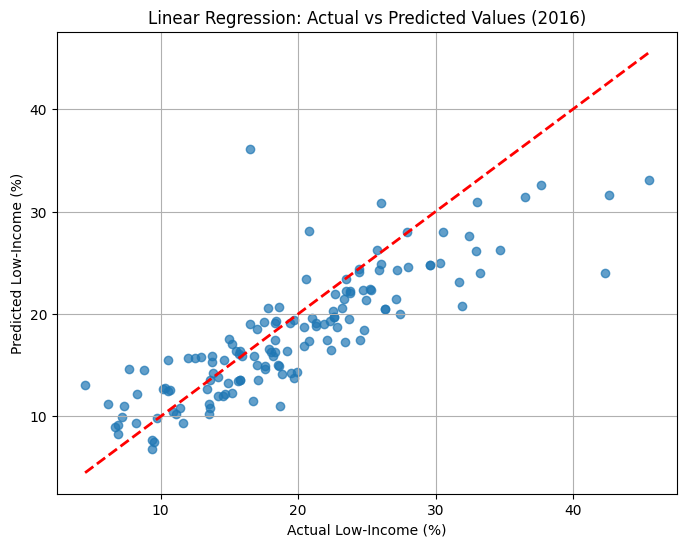

In [49]:
import matplotlib.pyplot as plt

print("=" * 60)
print("Actual vs Predicted Values")
print("=" * 60)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2)

plt.xlabel("Actual Low-Income (%)")
plt.ylabel("Predicted Low-Income (%)")
plt.title("Linear Regression: Actual vs Predicted Values (2016)")
plt.grid(True)

plt.show()

### Interpration 

The scatter plot compares the actual and predicted neighbourhood low-income prevalence values for the 2016 dataset. Most data points are distributed close to the 45-degree reference line, indicating that the Linear Regression model produces predictions that are generally consistent with the observed values. While a few neighbourhoods show larger deviations, particularly at higher low-income percentages, the overall pattern demonstrates a good fit and supports the model's ability to generalize across time. These results are consistent with the model's evaluation metrics and indicate satisfactory temporal predictive performance.

### Section 13: Residual Analysis

Assess the distribution of prediction errors (residuals) to determine whether the Linear Regression model satisfies the assumption that errors are randomly distributed without systematic patterns.

Residual Analysis


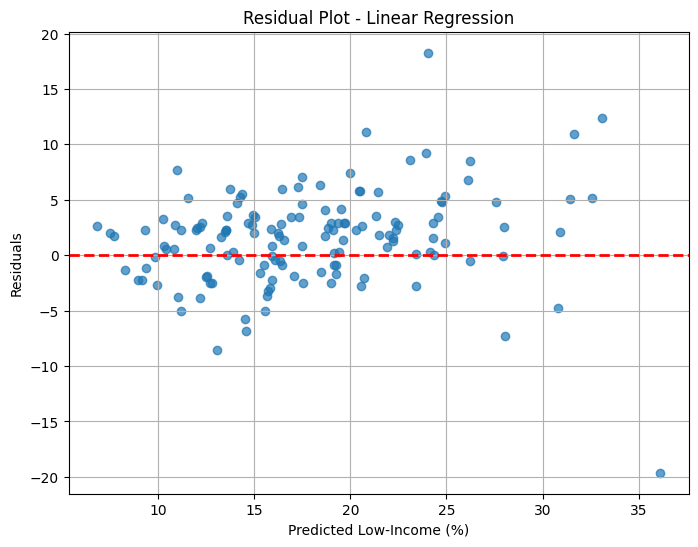

In [50]:
# --------------------------------------------
# Calculate residuals
# --------------------------------------------

residuals = y_test - y_pred_lr

print("=" * 60)
print("Residual Analysis")
print("=" * 60)

plt.figure(figsize=(8,6))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2)

plt.xlabel("Predicted Low-Income (%)")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.grid(True)

plt.show()

### Interpretation

The residual plot shows that the prediction errors are generally scattered around the zero reference line, with no clear systematic pattern or curvature. This suggests that the Linear Regression model provides a reasonable fit to the data and that the assumption of randomly distributed residuals is largely satisfied. Although a few neighbourhoods exhibit larger positive and negative residuals, particularly at higher predicted values, the overall distribution indicates that the model does not show significant bias and demonstrates satisfactory temporal predictive performance.

### Section 14: Residual Distribution

Examine the distribution of the residuals using a histogram to determine whether the prediction errors are approximately normally distributed. A roughly symmetric, bell-shaped distribution supports the assumptions of Linear Regression.

Residual Distribution


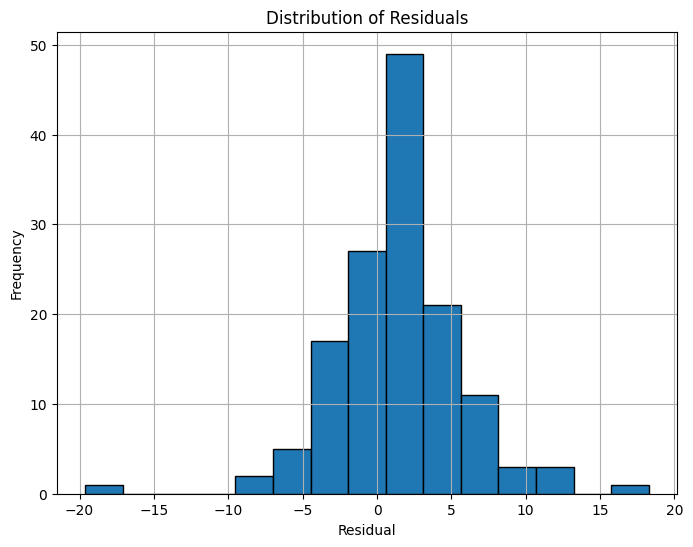

In [51]:
print("=" * 60)
print("Residual Distribution")
print("=" * 60)

plt.figure(figsize=(8,6))

plt.hist(residuals, bins=15, edgecolor="black")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)

plt.show()

### nterpretation

The histogram shows that the residuals are generally centered around zero and follow an approximately bell-shaped distribution. Most prediction errors are relatively small, with only a few larger positive and negative residuals. Although the distribution is not perfectly normal, it is sufficiently symmetric to support the assumptions of Linear Regression. Overall, the residual distribution indicates that the model is reliable and suitable for temporal prediction of neighbourhood low-income prevalence.

### Section 15: Temporal Model Validation Summary

Summarize the overall performance of the Linear Regression model when trained on the 2011 ML-ready dataset and evaluated on the independent 2016 ML-ready dataset. This section highlights the model's predictive accuracy, temporal generalization, and suitability for forecasting neighbourhood-level low-income prevalence

In [52]:
print("=" * 60)
print("Temporal Model Validation Summary")
print("=" * 60)

print(f"Training Dataset : 2011 ML-ready Dataset")
print(f"Testing Dataset  : 2016 ML-ready Dataset")

print()

print(f"R²      : {r2:.3f}")
print(f"MAE     : {mae:.3f}")
print(f"RMSE    : {rmse:.3f}")
print(f"MAPE    : {mape:.2f}%")
print(f"WAPE    : {wape:.2f}%")

Temporal Model Validation Summary
Training Dataset : 2011 ML-ready Dataset
Testing Dataset  : 2016 ML-ready Dataset

R²      : 0.666
MAE     : 3.377
RMSE    : 4.543
MAPE    : 19.36%
WAPE    : 17.30%


### Interpretation

The Linear Regression model demonstrated good temporal predictive performance when trained on the 2011 dataset and tested on the independent 2016 dataset. The evaluation metrics and diagnostic plots indicate that the model accurately captured the relationship between the selected socioeconomic indicators and neighbourhood low-income prevalence. The residual analyses showed no major violations of the regression assumptions, supporting the reliability of the model. Overall, the results suggest that historical socioeconomic characteristics can be used to effectively predict future neighbourhood-level low-income prevalence across Toronto.

### Section 16: Largest Prediction Errors by Neighbourhood

Identify the neighbourhoods with the largest prediction errors to better understand where the Linear Regression model performed well and where it struggled during temporal validation

In [53]:
# --------------------------------------------
# Create prediction comparison table
# --------------------------------------------

prediction_errors = pd.DataFrame({
    "Neighbourhood": test_df["Neighbourhood"],
    "Actual": y_test,
    "Predicted": y_pred_lr})

prediction_errors["Error"] = (
    prediction_errors["Predicted"] -
    prediction_errors["Actual"])

prediction_errors["Absolute_Error"] = (
    prediction_errors["Error"].abs())

# Sort by largest prediction errors
largest_errors = prediction_errors.sort_values(
    by="Absolute_Error",
    ascending=False)

print("=" * 60)
print("Top 10 Largest Prediction Errors")
print("=" * 60)

display(largest_errors.head(10))

Top 10 Largest Prediction Errors


,Neighbourhood,Actual,Predicted,Error,Absolute_Error
122,Waterfront Communities-The Island,16.5,36.130124,19.630124,19.630124
100,Regent Park,42.3,24.029179,-18.270821,18.270821
118,Thorncliffe Park,45.5,33.088956,-12.411044,12.411044
79,Moss Park,31.9,20.789438,-11.110562,11.110562
90,Oakridge,42.6,31.642936,-10.957064,10.957064
62,Kensington-Chinatown,33.2,23.958942,-9.241058,9.241058
107,Rustic,31.7,23.100386,-8.599614,8.599614
64,Kingsway South,4.5,13.055731,8.555731,8.555731
42,Flemingdon Park,34.7,26.227012,-8.472988,8.472988
110,South Riverdale,18.7,10.988190,-7.711810,7.711810


### Interpretation

The table identifies the neighbourhoods with the largest prediction errors during temporal validation. The largest overestimation occurred in Waterfront Communities–The Island, where the model predicted a substantially higher low-income prevalence than was observed. In contrast, the largest underestimations occurred in Regent Park, Thorncliffe Park, Moss Park, and Oakridge, indicating that the model underestimated low-income prevalence in these neighbourhoods. These larger errors likely reflect localized socioeconomic changes between 2011 and 2016 that were not fully captured by the selected predictor variables. Despite these outliers, the model maintained good overall predictive performance across most neighbourhoods, supporting its reliability for temporal prediction

### Summary

Research Question

**To what extent can a model trained using the 2011 Toronto Neighbourhood Profiles dataset accurately predict neighbourhood-level low-income prevalence in the independent 2016 dataset?**

Answer

This notebook addressed Research Question 3(b) by evaluating the extent to which historical socioeconomic indicators can predict future neighbourhood-level low-income prevalence. A Linear Regression model was trained using the 2011 machine-learning-ready dataset and evaluated on the independent 2016 machine-learning-ready dataset, providing a temporal assessment of model generalizability.

The model achieved an R² of 0.666, indicating that approximately 66.6% of the variation in neighbourhood-level Low Income After-Tax Percentage (LIM-AT) in 2016 was explained using socioeconomic relationships learned from the 2011 data. The model also achieved an MAE of 3.377, RMSE of 4.543, MAPE of 19.36%, and WAPE of 17.30%, demonstrating good predictive performance despite the five-year time gap between the training and testing datasets.

Diagnostic analyses, including the comparison of actual and predicted values, residual analysis, and model assumption testing, indicated that the Linear Regression model produced stable and reliable predictions while reasonably satisfying the assumptions of linear regression. Although a small number of neighbourhoods exhibited larger prediction errors, no major violations of model assumptions or influential observations were identified that would invalidate the model.

Overall, the results demonstrate that historical socioeconomic indicators remain meaningful predictors of future neighbourhood-level low-income prevalence. The findings therefore provide evidence that predictive models trained on historical neighbourhood data can generalize to future census periods and support the use of predictive analytics for long-term municipal planning, housing policy, and neighbourhood vulnerability assessment.